Found 1197 mask files in C:\Users\ullas\Documents\Datasets\MU-KAN-master\inputs\lizi\masks\0\train

0_mask.png
  stored mode: L; shape: (256, 256); dtype: uint8
  grayscale shape: (256, 256); dtype: uint8
  grayscale range: 0 to 255
  unique grayscale values (value, pixel count): [(0, 65224), (255, 312)]
  foreground fraction using >127: 0.48%

1000_mask.png
  stored mode: L; shape: (256, 256); dtype: uint8
  grayscale shape: (256, 256); dtype: uint8
  grayscale range: 0 to 255
  unique grayscale values (value, pixel count): [(0, 65339), (255, 197)]
  foreground fraction using >127: 0.30%

1001_mask.png
  stored mode: L; shape: (256, 256); dtype: uint8
  grayscale shape: (256, 256); dtype: uint8
  grayscale range: 0 to 255
  unique grayscale values (value, pixel count): [(0, 63812), (255, 1724)]
  foreground fraction using >127: 2.63%

1002_mask.png
  stored mode: L; shape: (256, 256); dtype: uint8
  grayscale shape: (256, 256); dtype: uint8
  grayscale range: 0 to 255
  unique graysca

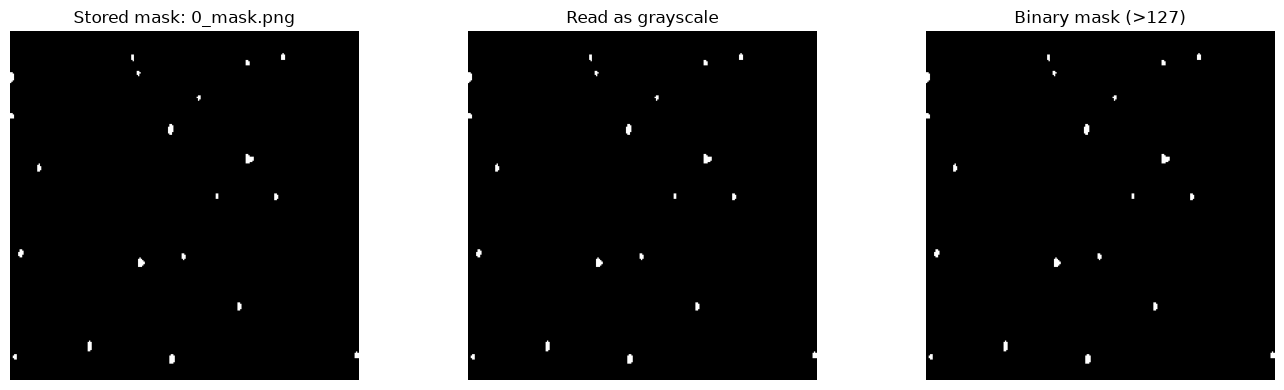

In [19]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

MASK_DIR = Path(r"C:\Users\ullas\Documents\Datasets\MU-KAN-master\inputs\lizi\masks\0\train")
mask_files = sorted(
    path for path in MASK_DIR.glob("*")
    if path.suffix.lower() in {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}
)

if not mask_files:
    print(f"No mask images found in {MASK_DIR.resolve()}")
else:
    print(f"Found {len(mask_files)} mask files in {MASK_DIR}")

    for path in mask_files[:5]:
        with Image.open(path) as image:
            stored = np.array(image)
            gray = np.array(image.convert("L"))
            image_mode = image.mode

        values, counts = np.unique(gray, return_counts=True)
        value_summary = list(zip(values[:20].tolist(), counts[:20].tolist()))
        print(f"\n{path.name}")
        print(f"  stored mode: {image_mode}; shape: {stored.shape}; dtype: {stored.dtype}")
        print(f"  grayscale shape: {gray.shape}; dtype: {gray.dtype}")
        print(f"  grayscale range: {gray.min()} to {gray.max()}")
        print(f"  unique grayscale values (value, pixel count): {value_summary}")
        if len(values) > 20:
            print(f"  ... {len(values)} unique values total")
        print(f"  foreground fraction using >127: {(gray > 127).mean():.2%}")

    # Pillow loads the stored mask; convert to grayscale for the >127 check.
    sample_path = mask_files[0]
    with Image.open(sample_path) as image:
        stored = np.array(image.convert("RGB"))
        gray = np.array(image.convert("L"))

    binary = (gray > 127).astype(np.uint8)
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(stored)
    axes[0].set_title(f"Stored mask: {sample_path.name}")
    axes[1].imshow(gray, cmap="gray")
    axes[1].set_title("Read as grayscale")
    axes[2].imshow(binary, cmap="gray", vmin=0, vmax=1)
    axes[2].set_title("Binary mask (>127)")
    for axis in axes:
        axis.axis("off")
    plt.tight_layout()
    plt.show()

In [13]:
mask_location = str(MASK_DIR / "0_mask.png")

from PIL import Image

mask_image = Image.open(mask_location)

mask_array = np.array(mask_image)

In [20]:
mask_array_normalized = np.array(mask_array > 127).astype(np.int32)  # Normalize to [0, 1] range

In [ ]:
print(f"Mask array shape: {mask_array.shape}, dtype: {mask_array.dtype}")
print(f"Normalized mask array shape: {mask_array_normalized.shape}, dtype: {mask_array_normalized.dtype}")

Mask array shape: (256, 256), dtype: uint8
Normalized mask array shape: (256, 256), dtype: int32


: 